In [1]:
# Automatic Google Colab setup: clones the repo to access the .py module
# and the dataset in this folder (no effect when run locally).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Base-Algorithms/04-Polynomial-Regression-Ridge")
    get_ipython().system('pip install -q openpyxl')


# Polynomial Regression with L2 Regularization (Ridge)

Translated from `Codigo01_Seno_Regularizacao.R`.

A high-degree polynomial fit by least squares tends to overfit noisy data
(it oscillates to chase every point). **Ridge regularization** penalizes
large coefficients, trading a bit of bias for an important reduction in
variance.

## Theory

Model: $\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_p x^p$
(here, $p=8$).

**OLS** minimizes only the squared error:

$$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$$

**Ridge** adds an $L_2$ penalty on the coefficients (except the intercept):

$$\hat{\beta}_{Ridge} = \underset{\beta}{\text{argmin}} \; \|y - X\beta\|^2 + \lambda\|\beta_{1:p}\|^2
= (X^TX + \lambda I')^{-1}X^Ty$$

where $I'$ is the identity matrix with its first entry (the intercept)
zeroed out, so the average level of the function is not penalized.

### What actually *is* the intercept?

The intercept ($\beta_0$) is the value the model predicts when every input
variable is zero. Here, when $x=0$, every power term also becomes zero
($0^1=0,\dots,0^8=0$), so $\hat{y} = \beta_0$ — the intercept is literally
the model's prediction at $x=0$. Unlike $\beta_1,\dots,\beta_8$, which
control the curve's *shape*, $\beta_0$ only shifts the whole curve up or
down without changing that shape. Penalizing it wouldn't fight overfitting
(which is about the curve being too wiggly) — it would just drag the
prediction's baseline level toward an arbitrary value (zero), regardless of
what the data's real scale is. That's why it's excluded from the penalty.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ridge_regularization import load_data, build_polynomial_features, fit_polynomial_ols, fit_ridge, predict

plt.rcParams["figure.figsize"] = (7, 4.5)


In [3]:
dt = load_data("data/Seno.xlsx")
x = dt["x"].to_numpy(dtype=float)
y = dt["y"].to_numpy(dtype=float)

X = build_polynomial_features(x, degree=8)
print("Design matrix shape (with intercept):", X.shape)


Design matrix shape (with intercept): (100, 9)


## OLS fit (degree-8 polynomial, no regularization)


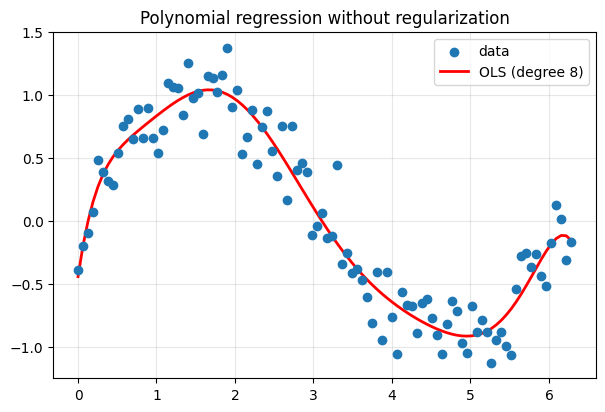

In [4]:
beta_ols = fit_polynomial_ols(X, y)
y_hat_ols = predict(X, beta_ols)

order = np.argsort(x)
plt.scatter(x, y, color="tab:blue", label="data", zorder=3)
plt.plot(x[order], y_hat_ols[order], color="red", lw=2, label="OLS (degree 8)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Polynomial regression without regularization")
plt.show()


## Ridge fit

### Choosing the hyperparameter

- **`lambda = 0.5`**: same value used in the original R script. It's a
  moderate value — large enough to visibly shrink the higher-degree
  coefficients (the ones that contribute most to overfitting), without
  flattening the fit so much that it loses the sine's real curvature.


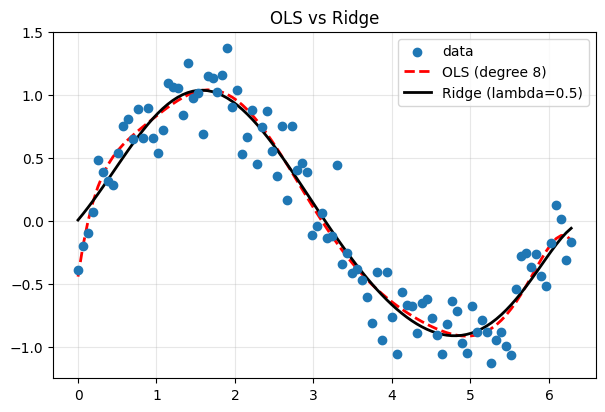

In [5]:
beta_ridge = fit_ridge(X, y, lam=0.5)
y_hat_ridge = predict(X, beta_ridge)

plt.scatter(x, y, color="tab:blue", label="data", zorder=3)
plt.plot(x[order], y_hat_ols[order], color="red", lw=2, ls="--", label="OLS (degree 8)")
plt.plot(x[order], y_hat_ridge[order], color="black", lw=2, label="Ridge (lambda=0.5)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("OLS vs Ridge")
plt.show()


### Why exclude the intercept from the penalty? A concrete demonstration

To make this tangible, let's shift the data so its true average level is
around 5 instead of 0, and compare what happens to the intercept with and
without penalizing it, across increasing values of lambda.


In [6]:
y_shifted = y + 5.0  # simulate data whose 'real' level is ~5, not ~0

print(f"Real data level (mean of y_shifted): {y_shifted.mean():.3f}\n")
print(f"{'lambda':<10}{'intercept WITHOUT penalizing':>30}{'intercept WITH penalizing':>28}")
for lam in [0.5, 5.0, 50.0]:
    beta_no_penalty = fit_ridge(X, y_shifted, lam, penalize_intercept=False)
    beta_with_penalty = fit_ridge(X, y_shifted, lam, penalize_intercept=True)
    print(f"{lam:<10}{beta_no_penalty[0]:>30.3f}{beta_with_penalty[0]:>28.3f}")


Real data level (mean of y_shifted): 5.029

lambda      intercept WITHOUT penalizing   intercept WITH penalizing
0.5                                5.010                       4.614
5.0                                5.286                       3.566
50.0                               5.523                       1.429


When the intercept is **not** penalized, it stays close to the data's real
level (~5) regardless of lambda. When it **is** penalized, it gets dragged
toward zero as lambda grows — at `lambda=50` the model would "believe" the
data's level is around 1.4, when it's actually 5. This is exactly why the
convention excludes the intercept: penalizing it doesn't reduce
overfitting, it just distorts the baseline of the prediction.


## Effect of regularization on the coefficients

Ridge shrinks (`shrinkage`) the coefficients toward zero — but doesn't zero
them out, unlike Lasso (L1). The chart below shows the magnitude of each
polynomial coefficient under both solutions.

**A caveat when reading this chart**: `x` ranges from 0 to ~6.28, but `x^8`
ranges from 0 to ~2.4 million. That means the degree-8 coefficient is
*already* tiny under OLS (it has to be small, since it multiplies a huge
number) — Ridge isn't what makes it look small, it was small before any
regularization. Comparing raw coefficients across such different degrees on
the same linear axis is misleading; the next cell shows the **percentage
reduction** per degree instead, which is comparable across degrees and
reveals that the shrinkage does **not** follow a simple "higher degree
shrinks more" pattern — collinearity between the polynomial terms makes the
real effect more complex than that intuition suggests.


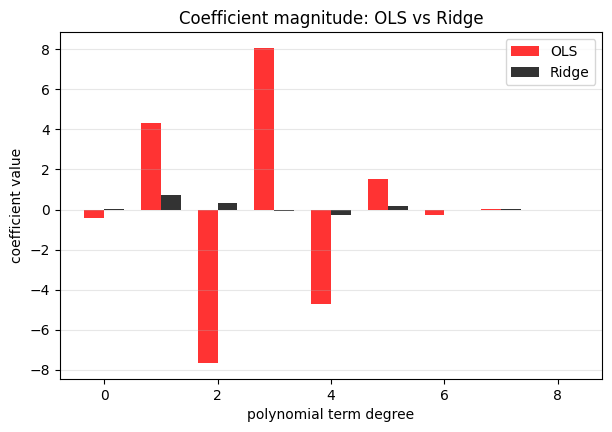

L2 norm of coefficients (excluding intercept) - OLS  : 12.9186
L2 norm of coefficients (excluding intercept) - Ridge: 0.8743


In [7]:
degrees = np.arange(len(beta_ols))
width = 0.35

plt.bar(degrees - width / 2, beta_ols, width, label="OLS", color="red", alpha=0.8)
plt.bar(degrees + width / 2, beta_ridge, width, label="Ridge", color="black", alpha=0.8)
plt.xlabel("polynomial term degree")
plt.ylabel("coefficient value")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.title("Coefficient magnitude: OLS vs Ridge")
plt.show()

print(f"L2 norm of coefficients (excluding intercept) - OLS  : {np.linalg.norm(beta_ols[1:]):.4f}")
print(f"L2 norm of coefficients (excluding intercept) - Ridge: {np.linalg.norm(beta_ridge[1:]):.4f}")


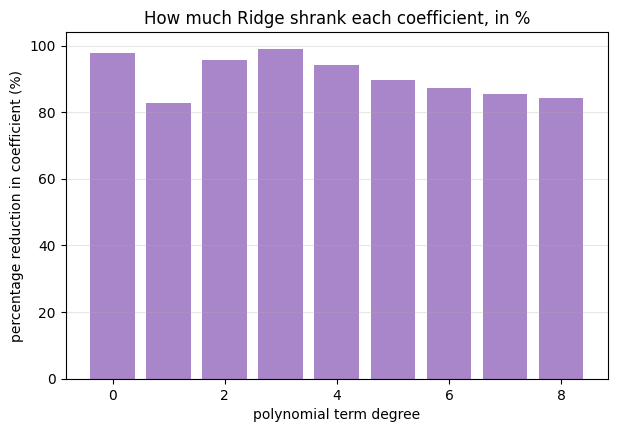

degree 0: 97.8% reduction
degree 1: 82.8% reduction
degree 2: 95.8% reduction
degree 3: 99.0% reduction
degree 4: 94.1% reduction
degree 5: 89.7% reduction
degree 6: 87.2% reduction
degree 7: 85.5% reduction
degree 8: 84.3% reduction


In [8]:
# Percentage reduction per degree (comparable across degrees, unlike raw values)
reduction_pct = (1 - np.abs(beta_ridge) / np.abs(beta_ols)) * 100

plt.bar(degrees, reduction_pct, color="tab:purple", alpha=0.8)
plt.xlabel("polynomial term degree")
plt.ylabel("percentage reduction in coefficient (%)")
plt.title("How much Ridge shrank each coefficient, in %")
plt.grid(alpha=0.3, axis="y")
plt.show()

for d, r in zip(degrees, reduction_pct):
    print(f"degree {d}: {r:.1f}% reduction")


## Coefficient stability across samples (bias-variance)

The real reason to accept Ridge (more training error) is **variance**:
large coefficients react strongly to a specific sample's noise; small
coefficients react little. To make this concrete, we simulate a second
sample of the same sine function (same underlying signal, different noise)
and compare how much the OLS and Ridge coefficients change between the two
samples.


OLS coefficient norm   -> sample 1: 12.919   sample 2: 3.042   change: 9.877
Ridge coefficient norm -> sample 1: 0.874   sample 2: 0.533   change: 0.341


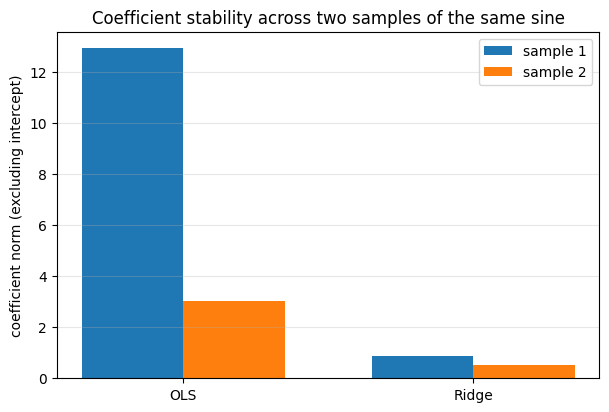

In [9]:
rng = np.random.default_rng(0)
noise_std = np.std(y - np.sin(x))
y_sample2 = np.sin(x) + rng.normal(0, noise_std, size=len(x))

beta_ols_2 = fit_polynomial_ols(X, y_sample2)
beta_ridge_2 = fit_ridge(X, y_sample2, lam=0.5)

norm_ols = [np.linalg.norm(beta_ols[1:]), np.linalg.norm(beta_ols_2[1:])]
norm_ridge = [np.linalg.norm(beta_ridge[1:]), np.linalg.norm(beta_ridge_2[1:])]

print(f"OLS coefficient norm   -> sample 1: {norm_ols[0]:.3f}   sample 2: {norm_ols[1]:.3f}   change: {abs(norm_ols[0]-norm_ols[1]):.3f}")
print(f"Ridge coefficient norm -> sample 1: {norm_ridge[0]:.3f}   sample 2: {norm_ridge[1]:.3f}   change: {abs(norm_ridge[0]-norm_ridge[1]):.3f}")

x_labels = ["OLS", "Ridge"]
bar_width = 0.35
positions = np.arange(2)
plt.bar(positions - bar_width/2, [norm_ols[0], norm_ridge[0]], bar_width, label="sample 1", color="tab:blue")
plt.bar(positions + bar_width/2, [norm_ols[1], norm_ridge[1]], bar_width, label="sample 2", color="tab:orange")
plt.xticks(positions, x_labels)
plt.ylabel("coefficient norm (excluding intercept)")
plt.title("Coefficient stability across two samples of the same sine")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()


The OLS coefficient set changes drastically between the two samples (the
norm swings widely) — the model is chasing each sample's specific noise,
not just the sine's underlying pattern. Ridge varies much less: that's the
real trade-off behind `lambda` — a bit more error *on this sample*, in
exchange for a model that generalizes better to new data, because it
doesn't memorize one sample's particular noise.


## Interpreting the metrics

We'd expect the OLS training RMSE to be slightly lower than Ridge's (OLS
minimizes training error exactly), but that doesn't mean better
generalization — the unregularized degree-8 polynomial tends to chase noise
specific to this one sample.


In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


print(f"OLS   -> RMSE: {rmse(y, y_hat_ols):.5f}, R2: {r_squared(y, y_hat_ols):.5f}")
print(f"Ridge -> RMSE: {rmse(y, y_hat_ridge):.5f}, R2: {r_squared(y, y_hat_ridge):.5f}")


OLS   -> RMSE: 0.18962, R2: 0.92924
Ridge -> RMSE: 0.20087, R2: 0.92059


## Conclusion

L2 regularization is a general complexity-control tool, applicable to
linear/polynomial regression as much as to a neural network's weights
(weight decay). The last notebook in this series
(`05-MLP-Hyperparameter-Search/`) returns to the MLP and systematically
explores how the number of neurons and the activation function affect the
bias-variance trade-off.
